# Wastewater-Based COVID-19 Hospitalization Forecasting

**6 treatment plants · 43 ZIP codes · 7–21 day predictive lag · 90.80% accuracy (WWTP) · 77.27% (ZIP code) · South Carolina 2020–21**

- R: spline smoothing and interpolation of raw RNA data
- Python: feature engineering, modeling, evaluation

**Stack:** `Python` `R` `Scikit-learn` `Statsmodels` `Pandas` `Random Forest` `Poisson Regression` `HalvingGridSearchCV`

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

from sklearn.model_selection import train_test_split

import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn import tree
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (f1_score,accuracy_score,recall_score,precision_score,confusion_matrix,roc_auc_score,precision_recall_curve,roc_curve,make_scorer,
)

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter("ignore", ConvergenceWarning)

In [ ]:
path =""
hosp_data = pd.read_csv(path)

path = ""
wwdata = pd.read_excel(path)

# Spline Smooth RNA Data WWTP

In [ ]:
path = ""
wwtp1_plm = pd.read_excel(path, usecols=['Date', 'Yhatu','Observed_RNA'])
path = ""
wwtp2_plm = pd.read_excel(path, usecols=['Date', 'Yhatu','Observed_RNA'])
path = ""
wwtp3_plm = pd.read_excel(path, usecols=['Date', 'Yhatu','Observed_RNA'])
path = ""
wwtp5_plm = pd.read_excel(path, usecols=['Date', 'Yhatu','Observed_RNA'])
path = ""
wwtp6_plm = pd.read_excel(path, usecols=['Date', 'Yhatu','Observed_RNA'])
path = ""
wwtp7_plm = pd.read_excel(path, usecols=['Date', 'Yhatu','Observed_RNA'])

wwtp2_plm.head()

,Yhatu,Date,Observed_RNA
0,2753.84,2020-04-19,520.00
1,3112.56,2020-04-20,NaN
2,3446.54,2020-04-21,NaN
3,3768.59,2020-04-22,520.00
4,4091.53,2020-04-23,NaN


In [ ]:
wwtp1_plm.rename(columns={'Yhatu': 'WWTP 1_rna','Observed_RNA': 'Observed_rna_WWTP 1'}, inplace=True)
wwtp2_plm.rename(columns={'Yhatu': 'WWTP 2_rna','Observed_RNA': 'Observed_rna_WWTP 2'}, inplace=True)
wwtp3_plm.rename(columns={'Yhatu': 'WWTP 3_rna','Observed_RNA': 'Observed_rna_WWTP 3'}, inplace=True)
wwtp5_plm.rename(columns={'Yhatu': 'WWTP 5_rna','Observed_RNA': 'Observed_rna_WWTP 5'}, inplace=True)
wwtp6_plm.rename(columns={'Yhatu': 'WWTP 6_rna','Observed_RNA': 'Observed_rna_WWTP 6'}, inplace=True)
wwtp7_plm.rename(columns={'Yhatu': 'WWTP 7_rna','Observed_RNA': 'Observed_rna_WWTP 7'}, inplace=True)
wwtp2_plm.head(1)

,WWTP 2_rna,Date,Observed_rna_WWTP 2
0,2753.84,2020-04-19,520.00


In [ ]:
merged_rna = wwtp1_plm.merge(wwtp2_plm, on='Date', how='outer') \
                        .merge(wwtp3_plm, on='Date', how='outer') \
                        .merge(wwtp5_plm, on='Date', how='outer') \
                        .merge(wwtp6_plm, on='Date', how='outer') \
                        .merge(wwtp7_plm, on='Date', how='outer')

merged_rna.info()

In [ ]:
merged_rna['Date'] = pd.to_datetime(merged_rna['Date'])

In [ ]:
def prepare_wwtp_data(merged_rnaa, wwtp_zip_map, start_date, end_date):

    merged_rna = merged_rnaa[(merged_rnaa['Date'] >= start_date) & (merged_rnaa['Date'] <= end_date)]
    
    wwdataframe = {}
    for wwtp, zip_codes in wwtp_zip_map.items():
        wwdataframe[wwtp] = merged_rna.loc[:, ['Date', f'{wwtp}_rna']]
    return wwdataframe

## Hospitalization

In [ ]:
hosp_data[['SEX']].isna().sum()
def create_label(row):
    if row['SEX'] == 'M':
        Gender = 'M'
    elif row['SEX'] == 'F':
        Gender = 'F'
    else:
        Gender = 'U'
    return f"{Gender}"

hosp_data['Gender_Label'] = hosp_data.apply(create_label, axis=1)
hospitalization_data = hosp_data[['ZIP','ADMD_new','Gender_Label']]#'Race_Age_Gender_Label']]

### Limiting hospitalization based on Considered time

In [ ]:
def process_hospitalization_data(hosp_data,start_date, end_date):

    hosp_data[['SEX']].isna().sum()
    def create_label(row):
        if row['SEX'] == 'M':
            Gender = 'M'
        elif row['SEX'] == 'F':
            Gender = 'F'
        else:
            Gender = 'U'
        return f"{Gender}"
    start_date,
    hosp_data['Gender_Label'] = hosp_data.apply(create_label, axis=1)
    hospitalization_data = hosp_data[['ZIP','ADMD_new','Gender_Label']]#'Race_Age_Gender_Label']]
    
    hosp_dataframes = {}
    hosp_weekly_dataframes = {}
    for wwtp, zip_codes in wwtp_zip_map.items():  
        filtered_hosp = hospitalization_data[hospitalization_data['ZIP'].isin(zip_codes)]
        filtered_hosp['ADMD_new'] = pd.to_datetime(filtered_hosp['ADMD_new'])
        filtered_hosp = filtered_hosp[(filtered_hosp['ADMD_new'] >= start_date) & (filtered_hosp['ADMD_new'] <= end_date)]
        daily_hosp = pd.crosstab(filtered_hosp['ADMD_new'], filtered_hosp['Gender_Label'])
        daily_hosp = daily_hosp.reset_index()
        if 'U' in daily_hosp.columns:
            daily_hosp['Daily_ADMD'] = daily_hosp['F'] + daily_hosp['M'] + daily_hosp['U']
        else:
            daily_hosp['Daily_ADMD'] = daily_hosp['F'] + daily_hosp['M']
    
        if 'U' in daily_hosp.columns:
            daily_hosp['Smoothed_ADMD'] = daily_hosp['F'] + daily_hosp['M'] + daily_hosp['U']
        else:
            daily_hosp['Smoothed_ADMD'] = daily_hosp['F'] + daily_hosp['M']
    
        wwdataframe[wwtp]['Date'] = pd.to_datetime(wwdataframe[wwtp]['Date'])
        daily_hosp['ADMD_new'] = pd.to_datetime(daily_hosp['ADMD_new'])
    
        non_matching_dates = wwdataframe[wwtp][~wwdataframe[wwtp]['Date'].isin(daily_hosp['ADMD_new'])]['Date']
        
        new_rows = pd.DataFrame({
            'ADMD_new': non_matching_dates,  # The missing dates
            'F': 0,  # Assign 0 to the F column for the missing dates
            'M' : 0, # Assign 0 to the M column for the missing dates
             'U' : 0,
            'Daily_ADMD' : 0,
            'Smoothed_ADMD' : 0
        })
    
        daily_hosp = pd.concat([daily_hosp, new_rows], ignore_index=True)
    
        daily_hosp = daily_hosp.sort_values(by='ADMD_new').reset_index(drop=True)
        no_matching_dates = wwdataframe[wwtp][~wwdataframe[wwtp]['Date'].isin(daily_hosp['ADMD_new'])]['Date']
        print(no_matching_dates)
        daily_hosp['Smoothed_ADMD'] = daily_hosp['Smoothed_ADMD'].rolling(window=7).mean()
        for i in range(6):
            daily_hosp.loc[i, 'Smoothed_ADMD'] = daily_hosp['Daily_ADMD'].iloc[:i+1].mean()
    
        hosp_dataframes[wwtp] = daily_hosp
    hosp_dataframes['WWTP 1'].head(10)
    return hosp_dataframes

### A single dataframe for all variables and log transform RNA

In [ ]:
def build_combined_wwtp_dataframe(wwtp_zip_map, wwdataframe, hosp_dataframes):

    results_intrp = []
    combined_df = pd.DataFrame()
    y_preds = {}
    y_preds_combos = {}
    y_tests = {}
    import math
    
    for wwtp, zip_codes in wwtp_zip_map.items():
        if wwtp not in y_preds:
            y_preds[wwtp] = {}
    
    for wwtp, zip_codes in wwtp_zip_map.items():
        filtered_wstwtr_matching = wwdataframe[wwtp]#[wwdataframe[wwtp]['Date']#.isin(hosp_dataframes[wwtp]['ADMD_new'])]
        filtered_hosp_matching = hosp_dataframes[wwtp]#[hosp_dataframes[wwtp]['ADMD_new'].isin(wwdataframe[wwtp]['Date'])]
    
        merged_df = pd.merge(filtered_wstwtr_matching[['Date', f'{wwtp}_rna']],
                             filtered_hosp_matching[['ADMD_new','Smoothed_ADMD']],
                             left_on='Date', right_on='ADMD_new', how='outer')
    
        merged_df.rename(columns={f'{wwtp}_rna': f'SARS_CoV_2_{wwtp}',
                                  'Smoothed_ADMD': f'Smoothed_ADMD_{wwtp}', 
    
                                 }, inplace=True)  
        if combined_df.empty:
            combined_df = merged_df
        else:
            combined_df = pd.merge(combined_df, merged_df[['Date', f'SARS_CoV_2_{wwtp}', f'Smoothed_ADMD_{wwtp}']], 
                                   on='Date', how='outer')
        smoothed_col = f'Smoothed_ADMD_{wwtp}'
        original_col = 'Daily_ADMD'
        
    return combined_df

In [ ]:
def log_tranform(combined_df):
    import re
    
    sars_cov2_cols_train = [col for col in combined_df.columns if re.search(r"SARS_CoV_2_WWTP \d+", col)]
    combined_df[sars_cov2_cols_train] = np.log1p(combined_df[sars_cov2_cols_train].to_numpy())
    return combined_df

In [ ]:
def build_train_test_dataframe(combined_df):

    split_ratio = 0.9
    
    train_combined_df = {}
    test_combined_df = {}
    
    combined_df['Date'] = pd.to_datetime(combined_df['Date'])
    
    split_idx = int(len(combined_df) * split_ratio)
    split_date = combined_df.loc[split_idx, 'Date'] if split_idx < len(combined_df) else df['Date'].max()
    
    train_combined_df = combined_df[combined_df['Date'] <= split_date].copy()
    test_combined_df = combined_df[combined_df['Date'] > split_date].copy()
    
    print(f"Split Date = {split_date.date()}, Train shape = {train_combined_df.shape}, Test shape = {test_combined_df.shape}")
    return train_combined_df, test_combined_df, split_date

### Lag in train data

In [ ]:
def generate_lagged_training_data(train_combined_df, wwtp_zip_map, lag_range):

    lagged_train_data_dict = {}  # Dictionary to store each lag's dataframe
    lagged_train_sars_dict = {}  # Dictionary to store each lag's dataframe
    train_combined_df_for_lag = {}
    lagged_train_dfss = pd.DataFrame()
    last_train_rna = {}
    last_train_days = {}
    
    for lag in lag_range:
    
        lagged_train_df = pd.DataFrame()
    
        lagged_columns = []
    
        for wwtp in wwtp_zip_map:
            lagged_column_name = f'Lagged_Smoothed_ADMD_{wwtp}_{lag}'
            lagged_train_df[lagged_column_name] = train_combined_df[f'Smoothed_ADMD_{wwtp}'].iloc[lag:].reset_index(drop=True)
            lagged_train_df['Date Hosp'] = train_combined_df['Date'].iloc[lag:].reset_index(drop=True)
    
            lagged_columns.append(lagged_column_name)
            lagged_train_dfss[f'SARS_CoV_2_{wwtp}'] = train_combined_df[f'SARS_CoV_2_{wwtp}'].iloc[:-lag].reset_index(drop=True)
           
            lagged_train_dfss[f'Date'] =train_combined_df['Date'].iloc[:-lag].reset_index(drop=True)
            last_train_rna[(wwtp, lag)] = train_combined_df[f'SARS_CoV_2_{wwtp}'].iloc[-lag:].reset_index(drop=True)
            last_train_days[(wwtp, lag)] = train_combined_df['Date'].iloc[-lag:].reset_index(drop=True)
    
        lagged_train_data_dict[lag] = lagged_train_df.dropna().reset_index(drop = True)
        lagged_train_sars_dict[lag] = lagged_train_dfss.dropna().reset_index(drop = True)
    return lagged_train_data_dict, lagged_train_sars_dict, last_train_rna, last_train_days

### Apply lag to test data, truncate the training portion accordingly, and merge with test set.

In [ ]:
def generate_lagged_test_data(test_combined_df, wwtp_zip_map, lag_range, last_train_rna, last_train_days):
    lagged_test_data_dict = {}  # Dictionary to store each lag's dataframe
    lagged_test_sars_dict = {}  # Dictionary to store each lag's dataframe
    test_combined_df_for_lag = {}
    lagged_test_dfss = pd.DataFrame()
    
    for lag in lag_range:
    
        lagged_test_df = pd.DataFrame()
    
        lagged_columns = []
    
        for wwtp in wwtp_zip_map:
            lagged_column_name = f'Lagged_Smoothed_ADMD_{wwtp}_{lag}'
            lagged_test_df[lagged_column_name] = test_combined_df[f'Smoothed_ADMD_{wwtp}']
            lagged_test_df['Date Hosp'] = test_combined_df['Date']
    
            lagged_columns.append(lagged_column_name)
            lagged_test_dfss[f'SARS_CoV_2_{wwtp}'] = pd.concat(
            [last_train_rna[(wwtp, lag)], test_combined_df[f'SARS_CoV_2_{wwtp}'].iloc[:-lag].reset_index(drop=True)]
            ).reset_index(drop=True)
            lagged_test_dfss[f'Date'] = pd.concat(
                [last_train_days[(wwtp, lag)], test_combined_df['Date'].iloc[:-lag].reset_index(drop=True)]
            ).reset_index(drop=True)
            
        lagged_test_data_dict[lag] = lagged_test_df.reset_index(drop = True)
        lagged_test_sars_dict[lag] = lagged_test_dfss.dropna().reset_index(drop = True)
        
    return lagged_test_data_dict, lagged_test_sars_dict

In [ ]:
def combine_lagged_dataframes(
    lag_range, 
    lagged_train_data_dict, 
    lagged_train_sars_dict, 
    lagged_test_data_dict, 
    lagged_test_sars_dict
):
    train_combined_df_for_lag = {}
    test_combined_df_for_lag = {}
    for lag in lag_range:
        train_combined_df_for_lag[lag] = pd.concat([lagged_train_data_dict[lag], lagged_train_sars_dict[lag]], axis=1)
        test_combined_df_for_lag[lag] = pd.concat([lagged_test_data_dict[lag], lagged_test_sars_dict[lag]], axis=1)

    return train_combined_df_for_lag, test_combined_df_for_lag

### Model

##### single wwtp

In [ ]:
def run_models_for_each_wwtps(train_combined_df_for_lag, test_combined_df_for_lag, wwtp_zip_map, lag_range):

    from sklearn.metrics import mean_absolute_error, r2_score
    from sklearn.linear_model import PoissonRegressor
    from sklearn.ensemble import RandomForestRegressor
    y_predslag = {}
    y_preds_comboslag = {}
    results_lag = []
    y_testlag = {} 
    
    models = {
        "Random Forest": RandomForestRegressor(random_state=42),
        "Poisson Regression": PoissonRegressor(),  # Added Poisson Regression with default parameter
    
    }
    
    for lag in lag_range:
    
        for wwtp, zip_codes in wwtp_zip_map.items():
            if wwtp not in y_predslag:
                y_predslag[wwtp] = {}
                y_testlag[wwtp] = {}
            if lag not in y_predslag[wwtp]:
                y_predslag[wwtp][lag] = {}
                y_testlag[wwtp][lag] = {}
    
    for lag in lag_range:
        print(f"\nProcessing data for lag {lag}...\n")
    
        for wwtp, zip_codes in wwtp_zip_map.items():
    
            X_train = train_combined_df_for_lag[lag][[f'SARS_CoV_2_{wwtp}']]
            y_train = train_combined_df_for_lag[lag][f'Lagged_Smoothed_ADMD_{wwtp}_{lag}'].round().astype(int)
            X_test = test_combined_df_for_lag[lag][[f'SARS_CoV_2_{wwtp}']]
            y_test = test_combined_df_for_lag[lag][f'Lagged_Smoothed_ADMD_{wwtp}_{lag}'].round().astype(int)
    
            y_testlag[wwtp][lag] = y_test
    
            for name, model in models.items():
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                y_predslag[wwtp][lag][name] = y_pred  # Store the test set predictions by model name
    
                if name == "Poisson Regression":
            
                    model_params = {
                        'WWTP': wwtp,
                        'Lag': lag,
                        'Model': name,
                        'Intercept': model.intercept_,
                        'Coefficients': model.coef_.tolist(),
                    }
            
                    if 'poisson_params_list' not in locals():
                        poisson_params_list = []
            
                    poisson_params_list.append(model_params)
        
                def percentage_agreement(y_test, y_pred):
                    min_values = np.minimum(y_test, y_pred)
                    max_values = np.maximum(y_test, y_pred)
                    max_values[max_values == 0] = 1e-9
                    agreement = (min_values / max_values) * 100
                    return agreement
                def smape(y_true, y_pred):
                    y_true, y_pred = np.array(y_true).flatten(), np.array(y_pred).flatten()  # Ensure 1D arrays
                    return np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100
                
                def mape(y_true, y_pred):
                    y_true, y_pred = np.array(y_true).flatten(), np.array(y_pred).flatten()  # Ensure 1D arrays
                    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
                def rmsee(y_true, y_pred):
                    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
                    return rmse
    
                pa = percentage_agreement(y_test, y_pred)
                results_lag.append({
                   'WWTP': wwtp,
                    'Model': name,
                    'Lag': lag,
                    'Percentage Agreement': pa,
                 })
                
    results_df = pd.DataFrame(results_lag)
    
    pivot_df = results_df.pivot(index=['WWTP', 'Lag'], columns='Model', values='Percentage Agreement')
    poisson_params_df = pd.DataFrame(poisson_params_list)

    return results_df, pivot_df, poisson_params_df, y_predslag, y_testlag

##### ALL WWTP

In [ ]:
def run_models_for_all_wwtps(
    train_combined_df_for_lag,
    test_combined_df_for_lag,
    lag_range,
    wwtp_zip_map,
    models
):    
    
    y_predslag = {}
    y_preds_comboslag = {}
    results_lag = []
    y_testlag = {} 
    
    models = {
        "Random Forest": RandomForestRegressor(random_state=42),
        "Poisson Regression": PoissonRegressor(),  # Added Poisson Regression with default parameter
    
    }
    
    def percentage_agreement(y_test, y_pred):
                    min_values = np.minimum(y_test, y_pred)
                    max_values = np.maximum(y_test, y_pred)
                    max_values[max_values == 0] = 1e-9
                    agreement = (min_values / max_values) * 100
                    return agreement
    def smape(y_true, y_pred):
                    y_true, y_pred = np.array(y_true).flatten(), np.array(y_pred).flatten()  # Ensure 1D arrays
                    return np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100
                
    def mape(y_true, y_pred):
                    y_true, y_pred = np.array(y_true).flatten(), np.array(y_pred).flatten()  # Ensure 1D arrays
                    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    def rmsee(y_true, y_pred):
                    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
                    return rmse
    
    for lag in lag_range:
    
        for wwtp, zip_codes in wwtp_zip_map.items():
            if wwtp not in y_predslag:
                y_predslag[wwtp] = {}
                y_testlag[wwtp] = {}
            if lag not in y_predslag[wwtp]:
                y_predslag[wwtp][lag] = {}
                y_testlag[wwtp][lag] = {}
    
    for lag in lag_range:
        print(f"\nProcessing data for lag {lag}...\n")
    
        for wwtp, zip_codes in wwtp_zip_map.items():
    
            drop_cols = ['Date'] + ['Date Hosp'] + [f'Lagged_Smoothed_ADMD_WWTP 1_{lag}'] +[f'Lagged_Smoothed_ADMD_WWTP 2_{lag}'] + [f'Lagged_Smoothed_ADMD_WWTP 3_{lag}'] + [f'Lagged_Smoothed_ADMD_WWTP 5_{lag}'] +[f'Lagged_Smoothed_ADMD_WWTP 6_{lag}'] +[f'Lagged_Smoothed_ADMD_WWTP 7_{lag}']
            X_train = train_combined_df_for_lag[lag].drop(columns=drop_cols)
            y_train = train_combined_df_for_lag[lag][f'Lagged_Smoothed_ADMD_{wwtp}_{lag}'].round().astype(int)
    
            X_test = test_combined_df_for_lag[lag].drop(columns=drop_cols)
            y_test = test_combined_df_for_lag[lag][f'Lagged_Smoothed_ADMD_{wwtp}_{lag}'].round().astype(int)
            y_testlag[wwtp][lag] = y_test
    
            for name, model in models.items():
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                y_predslag[wwtp][lag][name] = y_pred  # Store the test set predictions by model name
    
                if name == "Poisson Regression":
            
                    model_params = {
                        'WWTP': wwtp,
                        'Lag': lag,
                        'Model': name,
                        'Intercept': model.intercept_,
                        'Coefficients': model.coef_.tolist(),
                    }
            
                    if 'poisson_params_list' not in locals():
                        poisson_params_list = []
            
                    poisson_params_list.append(model_params)
        
                pa = percentage_agreement(y_test, y_pred)
                results_lag.append({
                   'WWTP': wwtp,
                    'Model': name,
                    'Lag': lag,
                    'Percentage Agreement': pa,
                 })
                
    results_df = pd.DataFrame(results_lag)
    
    pivot_df = results_df.pivot(index=['WWTP', 'Lag'], columns='Model', values='Percentage Agreement')
    poisson_params_df = pd.DataFrame(poisson_params_list)
    return results_df, y_predslag, y_testlag, poisson_params_df

##### Statsmodel api with poisson

In [ ]:
def run_statsmodels_poisson_all_wwtps(train_combined_df_for_lag, test_combined_df_for_lag, wwtp_zip_map, lag_range):
    models = {
        "Poisson Regression": None  # Placeholder – we'll use statsmodels below
    }
    
    y_predslag = {}
    y_testlag = {}
    y_preds_comboslag = {}
    poisson_params_list = []
    
    for lag in lag_range:
        for wwtp, zip_codes in wwtp_zip_map.items():
            if wwtp not in y_predslag:
                y_predslag[wwtp] = {}
                y_testlag[wwtp] = {}
                y_preds_comboslag[wwtp] = {}
    
            if lag not in y_predslag[wwtp]:
                y_predslag[wwtp][lag] = {}
                y_testlag[wwtp][lag] = {}
                y_preds_comboslag[wwtp][lag] = {}
    
            drop_cols = ['Date'] + ['Date Hosp'] + [f'Lagged_Smoothed_ADMD_WWTP 1_{lag}'] +[f'Lagged_Smoothed_ADMD_WWTP 2_{lag}'] + [f'Lagged_Smoothed_ADMD_WWTP 3_{lag}'] + [f'Lagged_Smoothed_ADMD_WWTP 5_{lag}'] +[f'Lagged_Smoothed_ADMD_WWTP 6_{lag}'] +[f'Lagged_Smoothed_ADMD_WWTP 7_{lag}']
            X_train = train_combined_df_for_lag[lag].drop(columns=drop_cols)
            y_train = train_combined_df_for_lag[lag][f'Lagged_Smoothed_ADMD_{wwtp}_{lag}'].round().astype(int)
    
            X_test = test_combined_df_for_lag[lag].drop(columns=drop_cols)
            y_test = test_combined_df_for_lag[lag][f'Lagged_Smoothed_ADMD_{wwtp}_{lag}'].round().astype(int)
            y_testlag[wwtp][lag] = y_test
            
            model_name = "Poisson Regression"
            X_train_sm = sm.add_constant(X_train)
            X_test_sm = sm.add_constant(X_test)
    
            poisson_model = sm.GLM(y_train, X_train_sm, family=sm.families.Poisson()).fit()
            y_pred = poisson_model.predict(X_test_sm)
    
            y_predslag[wwtp][lag][model_name] = y_pred
    
            for feature, coef, pval in zip(X_train_sm.columns, poisson_model.params, poisson_model.pvalues):
              if feature != 'const' and pval < 0.05:
                poisson_params_list.append({
                    'WWTP': wwtp,
                    'Lag': lag,
                    'Model': model_name,
                    'Feature': feature,
                    'Coefficient': coef,
                    'P-value': pval
                })
    
    poisson_params_df = pd.DataFrame(poisson_params_list)
    
    print(poisson_params_df)
    return y_predslag, y_testlag, poisson_params_df

### Result Plot

In [ ]:
def plot_predictions_and_hospitalizations(
    train_combined_df_for_lag,
    test_combined_df_for_lag,
    lagged_test_sars_dict,
    y_predslag,
    wwtp_zip_map,
    lag_range,
    models,
    show_rna=False
):
    wwtp_display_names = {
    'WWTP 1_rna': 'Richland (Metro)',
    'WWTP 2_rna': 'Richland (ER)',
    'WWTP 3_rna': 'Lexington (Caycee)',
    'WWTP 5_rna': 'York (Rock Hill)',
    'WWTP 6_rna': 'Charleston (PI)',
    'WWTP 7_rna': 'Charleston (MP)',}
    for lag in lag_range:
        for wwtp in wwtp_zip_map.keys():
            train_dates = train_combined_df_for_lag[lag]['Date Hosp']
            y_train = train_combined_df_for_lag[lag][f'Lagged_Smoothed_ADMD_{wwtp}_{lag}']
    
            test_dates = test_combined_df_for_lag[lag]['Date Hosp']
            y_test = test_combined_df_for_lag[lag][f'Lagged_Smoothed_ADMD_{wwtp}_{lag}']
            test_start_date = pd.to_datetime(test_dates.iloc[0])

            fig, ax1 = plt.subplots(figsize=(14, 6))
    
            line1 = ax1.plot(train_dates, y_train, label='Train Hosp', color='green', linewidth=2)
            line2 = ax1.plot(test_dates, y_test.values, label='Test Hosp', color='red', linewidth=2)
            ax1.axvline(x=test_start_date, linestyle='--', linewidth=3, color='lightgreen', label='Hosp Train/Test')

            model_lines = []
            for model_name in models.keys():
                if model_name in y_predslag[wwtp][lag]:
                    y_pred = y_predslag[wwtp][lag][model_name]
                    model_line, = ax1.plot(test_dates, y_pred, linestyle='--', linewidth=2, label=f'{model_name}')
                    model_lines.append(model_line)
    
            rna_df = lagged_test_sars_dict[lag]  
            rna_col = f'SARS_CoV_2_{wwtp}'  
            
            rna_dates = pd.to_datetime(rna_df['Date'].reset_index(drop=True))  # RNA dates
            rna_values = rna_df[rna_col].reset_index(drop=True)
            
            test_start_date_rna = rna_dates.iloc[0]
            
            ax2 = ax1.twinx()
            
            rna_line, = ax2.plot(rna_dates, rna_values,
                                 color='blue', alpha=0.6, linewidth=2, label='RNA Copies')
            
            ax2.set_ylabel('SARS-CoV-2 RNA Copies', color='blue', fontsize=25)
            ax2.tick_params(axis='y', labelcolor='blue', labelsize=20)
            
            ax2.axvline(x=test_start_date_rna, linestyle=':', linewidth=3, color='grey', label='RNA Train/Test')
            
            lines_1, labels_1 = ax1.get_legend_handles_labels()
            lines_2, labels_2 = ax2.get_legend_handles_labels()
            
            ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize='15')
            all_values = pd.concat([y_train, y_test] + 
                                   [pd.Series(y_predslag[wwtp][lag][model]) 
                                    for model in models if model in y_predslag[wwtp][lag]])
            
            max_val = np.nanmax(all_values)
            interval = max_val / 4
            yticks = np.round(np.arange(0, max_val + interval, interval)).astype(int)
            ax1.set_yticks(yticks)
            ax1.tick_params(axis='y', labelsize=20)  # Set font size
            ax1.tick_params(axis='x', labelsize=15)  # Set x-axis font size
            plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')  # Rotate x-axis labels
            
            plt.title(f'{wwtp_display_names.get(f"{wwtp}_rna", wwtp)} | Lag: {lag} | Hospitalizations and RNA Split', fontsize=30)
            ax1.set_xlabel('Date', fontsize = 20)
            ax1.set_ylabel('Hospitalizations',fontsize = 20)
            ax1.grid(True)
            fig.tight_layout()
            plt.show()

### Weekly PA

In [ ]:
def evaluate_weekly_percentage_agreement(y_predslag, y_testlag, lag_range, wwtp_zip_map, models):

    results_lag = {}
    y_pred_weekly_sums = {}
    
    export_data = []
    
    for lag in lag_range:
    
        for wwtp, zip_codes in wwtp_zip_map.items():
    
            for model_name in models:
                y_pred_model = pd.Series(np.ravel(y_predslag[wwtp][lag][model_name]), name=f'{model_name} Prediction Lag {lag}')
                y_test_wwtp = pd.Series(np.ravel(y_testlag[wwtp][lag]), name=f'Test Values Lag {lag}')
    
                week_numbers = y_pred_model.index // 7
                
                df_weekly = pd.DataFrame({
                    'y_pred': y_pred_model,
                    'y_test': y_test_wwtp,
                    'week': week_numbers
                })
                
                y_pred_weekly_sum = y_pred_model.groupby(y_pred_model.index // 7).sum()
                y_test_weekly_sum = y_test_wwtp.groupby(y_test_wwtp.index // 7).sum()
    
                if wwtp not in y_pred_weekly_sums:
                    y_pred_weekly_sums[wwtp] = {}
                if lag not in y_pred_weekly_sums[wwtp]:
                    y_pred_weekly_sums[wwtp][lag] = {}
    
                y_pred_weekly_sums[wwtp][lag][model_name] = y_pred_weekly_sum
                
                print(y_pred_weekly_sum)     
                weeks = range(len(y_test_weekly_sum))
                
                def percentage_agreement(y_test, y_pred):
                    min_value = min(y_test, y_pred)
                    max_value = max(y_test, y_pred)
                    if max_value == 0:
                        max_value = 1e-9
                    return (min_value / max_value) * 100
    
                def smape(y_true, y_pred):
                    y_true, y_pred = np.array(y_true).flatten(), np.array(y_pred).flatten()
                    return np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100
                
                def mape(y_true, y_pred):
                    y_true, y_pred = np.array(y_true).flatten(), np.array(y_pred).flatten()
                    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
                weekly_percentage_agreements = []
                for week in range(len(y_test_weekly_sum)):
                    y_test_week = y_test_weekly_sum.iloc[week]
                    y_pred_week = y_pred_weekly_sum.iloc[week]
    
                    pa_week = percentage_agreement(y_test_week, y_pred_week)
                    weekly_percentage_agreements.append(pa_week)
                    
                    export_data.append({
                        'WWTP': wwtp,
                        'Model': model_name,
                        'Lag': lag,
                        'Week': week + 1,
                        'Percentage Agreement': pa_week,
                    })
            print(y_test_weekly_sum)
     
    export_df = pd.DataFrame(export_data)
    return export_df, y_pred_weekly_sums

### Average wrt WWTP for each Model for each Lag and then find the median value of that and Plotting the median PA

In [ ]:
def summarize_model_performance(
    export_df,
    models_to_plot=['Poisson Regression', 'Random Forest'],
    output_prefix='WWTP_Model',
    save_excel=True,
    save_plot=True,
    plot_filename='median_percentage_agreement_by_lag.png'):
    wwtp_model_avg_pa = export_df.groupby(['WWTP', 'Model', 'Lag'])['Percentage Agreement'].mean().reset_index()
    
    wwtp_model_avg_pa['Percentage Agreement'] = wwtp_model_avg_pa['Percentage Agreement'].round(2)
    
    model_summary_from_wwtp_avg = wwtp_model_avg_pa.groupby(['Model','Lag'])['Percentage Agreement'].agg(
        Min='min',
        Q1=lambda x: x.quantile(0.25),
        Mean='mean',
        Median='median',
        Q3=lambda x: x.quantile(0.75),
        Max='max'
    ).reset_index()
    
    model_summary_from_wwtp_avg['IQR'] = model_summary_from_wwtp_avg['Q3'] - model_summary_from_wwtp_avg['Q1']
    
    model_summary_from_wwtp_avg = model_summary_from_wwtp_avg.round(2)
    
    models_to_plot = ['Poisson Regression', 'Random Forest']
    filtered_stats = model_summary_from_wwtp_avg[model_summary_from_wwtp_avg['Model'].isin(models_to_plot)]
    
    pivot_df = filtered_stats.pivot(index='Lag', columns='Model', values='Median')
    
    plt.figure(figsize=(10, 6))
    for model in models_to_plot:
        plt.plot(pivot_df.index, pivot_df[model], marker='o', label=model)
    
    plt.title('Median Percentage Agreement by Lag')
    plt.xlabel('Lag (days)')
    plt.ylabel('Median Percentage Agreement (%)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    
    plt.show()
    return wwtp_model_avg_pa, model_summary_from_wwtp_avg

In [ ]:
def tune_random_forest_with_percentage_agreement(train_combined_df_for_lag, test_combined_df_for_lag, wwtp_zip_map, lag_range):

    from sklearn.metrics import make_scorer
    from sklearn.experimental import enable_halving_search_cv  # noqa
    from sklearn.model_selection import HalvingGridSearchCV
    
    def percentage_agreement(y_true, y_pred):
        min_vals = np.minimum(y_true, y_pred)
        max_vals = np.maximum(y_true, y_pred)
        return np.mean(min_vals / max_vals)*100
    
    pa_scorer = make_scorer(percentage_agreement, greater_is_better=True)
    
    rf_param_grid = {
        'n_estimators': [1500, 2000, 3000, 4000, 5000],          # Number of trees
        'max_depth': [10, None],                # Tree depth
    }
    
    y_predslag = {}
    y_testlag = {}
    results_lag = []
    best_rf_params = {}
    
    for lag in lag_range:
        print(f"\nProcessing data for lag {lag}...\n")
    
        for wwtp, zip_codes in wwtp_zip_map.items():
            feature_cols = [col for col in train_combined_df_for_lag[lag].columns
                            if "Lagged_Smoothed_ADMD_" not in col and col != 'Date' and col != "Date Hosp"]
            
            X_train = train_combined_df_for_lag[lag][feature_cols]
            y_train = train_combined_df_for_lag[lag][f'Lagged_Smoothed_ADMD_{wwtp}_{lag}'].round().astype(int)
    
            rf = RandomForestRegressor(random_state=42)
            rf_search = HalvingGridSearchCV(
                estimator=rf,
                param_grid=rf_param_grid,
                scoring=pa_scorer,
                cv=5,
                factor=2,
                n_jobs=-1
            )
            rf_search.fit(X_train, y_train)
            best_rf = rf_search.best_estimator_
            results_lag.append({
                'wwtp': wwtp,
                'lag': lag,
            })
            best_rf_params[(wwtp, lag)] = rf_search.best_params_
    
    return results_lag, best_rf_params

In [ ]:
def evaluate_best_rf_predictions_weekly(train_combined_df_for_lag, test_combined_df_for_lag,
                                        wwtp_zip_map, lag_range, best_rf_params):
    y_predslag_best = {}
    y_testlag_best = {}
    results_lag_best = []
    weekly_results = []
    weekly_preds = {}
    
    def percentage_agreement(y_true, y_pred):
        min_vals = np.minimum(y_true, y_pred)
        max_vals = np.maximum(y_true, y_pred)
        return (min_vals / max_vals)*100
    for lag in lag_range:
        print(f"\nRe-running test predictions using best hyperparameters for lag {lag}...\n")
    
        for wwtp, zip_codes in wwtp_zip_map.items():
            best_params = best_rf_params.get((wwtp, lag), None)
            if best_params is None:
                print(f"Skipping {wwtp}, lag {lag} — no best params found.")
                continue
    
            feature_cols = [col for col in test_combined_df_for_lag[lag].columns
                            if "Lagged_Smoothed_ADMD_" not in col and col != 'Date' and col != 'Date Hosp']
            
            X_train = train_combined_df_for_lag[lag][feature_cols]
            y_train = train_combined_df_for_lag[lag][f'Lagged_Smoothed_ADMD_{wwtp}_{lag}'].round().astype(int)
    
            X_test = test_combined_df_for_lag[lag][feature_cols]
            y_test = test_combined_df_for_lag[lag][f'Lagged_Smoothed_ADMD_{wwtp}_{lag}'].round().astype(int)
    
            rf_best = RandomForestRegressor(random_state=42, **best_params)
            rf_best.fit(X_train, y_train)
            y_pred = rf_best.predict(X_test)
    
            y_pred_model = pd.Series(np.ravel(y_pred), index=np.arange(len(y_pred)), name=f'RandomForest Prediction Lag {lag}')
            y_test_wwtp = pd.Series(np.ravel(y_test), index=np.arange(len(y_test)), name=f'Test Values Lag {lag}')
    
            y_pred_weekly_sum = y_pred_model.groupby(y_pred_model.index // 7).sum()
            y_test_weekly_sum = y_test_wwtp.groupby(y_test_wwtp.index // 7).sum()
    
            pa = percentage_agreement(y_test_weekly_sum, y_pred_weekly_sum)
    
            y_predslag_best[(wwtp, lag)] = y_pred
            y_testlag_best[(wwtp, lag)] = y_test
    
            weekly_preds[(wwtp, lag)] = pd.DataFrame({
                'WWTP': wwtp,
                'Lag': lag,
                'Week': y_pred_weekly_sum.index,
                'Weekly_Predicted': y_pred_weekly_sum.values,
                'Weekly_Actual': y_test_weekly_sum.values
            })
    
            results_lag_best.append({
                'wwtp': wwtp,
                'lag': lag,
                'Percentage Agreement': pa,
            })
            for week in range(len(y_pred_weekly_sum)):
                  y_true = y_test_weekly_sum.loc[week]
                  y_pred_val = y_pred_weekly_sum.loc[week]
                  weekly_results.append({
                    'WWTP': wwtp,
                    'Lag': lag,
                    'Week': week+1,
                    'Weekly_Actual': y_true,
                    'Weekly_Predicted': y_pred_val,
                    'Percentage Agreement': percentage_agreement(y_true, y_pred_val),
                })
        results_df = pd.DataFrame(results_lag_best)
        weekly_results_df = pd.DataFrame(weekly_results)
    
        return y_predslag_best, y_testlag_best, results_df, weekly_results_df, weekly_preds, weekly_results

In [ ]:
def summarize_lag_performance_with_wwtp_avg(results_lag_best):
    """
    1. Computes average Percentage Agreement per WWTP per lag.
    2. Then summarizes stats across WWTPs for each lag (Min, Q1, Mean, Median, Q3, Max, IQR).
    
    Parameters:
        results_lag_best (list of dicts): Weekly evaluation output for Random Forest predictions.
        
    Returns:
        pd.DataFrame: Summary statistics per lag after WWTP-level averaging.
    """
    reslt_df = pd.DataFrame(results_lag_best)

    wwtp_lag_avg = reslt_df.groupby(['WWTP', 'Lag'])['Percentage Agreement'].mean().reset_index()

    lag_summary_stats = wwtp_lag_avg.groupby('Lag')['Percentage Agreement'].agg(
        Min='min',
        Q1=lambda x: x.quantile(0.25),
        Mean='mean',
        Median='median',
        Q3=lambda x: x.quantile(0.75),
        Max='max'
    ).reset_index()

    lag_summary_stats['IQR'] = lag_summary_stats['Q3'] - lag_summary_stats['Q1']
    
    return lag_summary_stats.round(2)

### Running functions

Series([], Name: Date, dtype: datetime64[ns])
Series([], Name: Date, dtype: datetime64[ns])
Series([], Name: Date, dtype: datetime64[ns])
Series([], Name: Date, dtype: datetime64[ns])
Series([], Name: Date, dtype: datetime64[ns])
Series([], Name: Date, dtype: datetime64[ns])
Split Date = 2021-01-05, Train shape = (262, 14), Test shape = (28, 14)

Processing data for lag 5...


Processing data for lag 7...


Processing data for lag 14...


Processing data for lag 21...



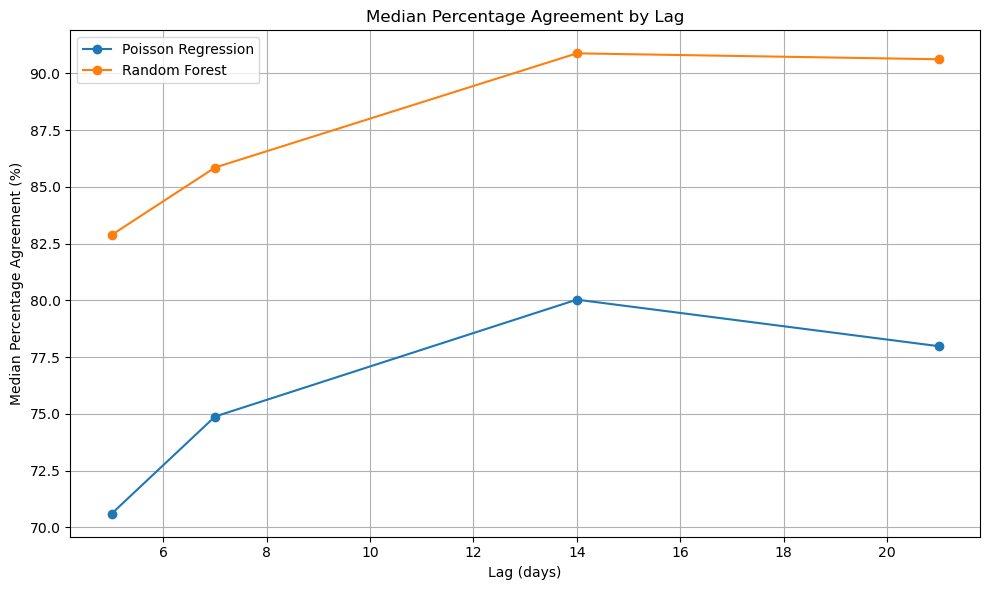

In [ ]:
start_date = '2020-04-19'
end_date = '2021-02-02'
lag_range = [5, 7, 14, 21]

wwdataframe = prepare_wwtp_data(merged_rna, wwtp_zip_map, start_date, end_date)

hosp_dataframes = process_hospitalization_data(hosp_data,start_date, end_date)

combined_df = build_combined_wwtp_dataframe(wwtp_zip_map, wwdataframe, hosp_dataframes)

combined_dff =  log_tranform(combined_df)
train_combined_df, test_combined_df, split_date = build_train_test_dataframe(combined_dff)

lagged_train_data_dict, lagged_train_sars_dict, last_train_rna, last_train_days = generate_lagged_training_data(
    train_combined_df=train_combined_df,
    wwtp_zip_map=wwtp_zip_map,
    lag_range=lag_range
)
lagged_test_data_dict, lagged_test_sars_dict = generate_lagged_test_data(
    test_combined_df=test_combined_df,
    wwtp_zip_map=wwtp_zip_map,
    lag_range=lag_range,
    last_train_rna=last_train_rna,
    last_train_days=last_train_days
)
train_combined_df_for_lag, test_combined_df_for_lag = combine_lagged_dataframes(
    lag_range,
    lagged_train_data_dict,
    lagged_train_sars_dict,
    lagged_test_data_dict,
    lagged_test_sars_dict
)
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import PoissonRegressor
import statsmodels.api as sm

models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "Poisson Regression": PoissonRegressor()
}

results_df, y_predslag, y_testlag, poisson_params_df = run_models_for_all_wwtps(
    train_combined_df_for_lag,
    test_combined_df_for_lag,
    lag_range,
    wwtp_zip_map,
    models
)

plot_predictions_and_hospitalizations(
    train_combined_df_for_lag=train_combined_df_for_lag,
    test_combined_df_for_lag=test_combined_df_for_lag,
    lagged_test_sars_dict=lagged_test_sars_dict,
    y_predslag=y_predslag,
    wwtp_zip_map=wwtp_zip_map,
    lag_range=lag_range,
    models=models,
    show_rna=True  # or False if you do not rna lines
)

export_df, y_pred_weekly_sums = evaluate_weekly_percentage_agreement(
    y_predslag=y_predslag,
    y_testlag=y_testlag,
    lag_range=lag_range,
    wwtp_zip_map=wwtp_zip_map,
    models=models
)
wwtp_model_avg_pa, model_summary_from_wwtp_avg = summarize_model_performance(
    export_df,
    models_to_plot=['Poisson Regression', 'Random Forest'],
    output_prefix='WWTP_Model',
    plot_filename='median_percentage_agreement_by_lag.png'
)